# LSC Robustness Figures

This notebook creates one appendix-style robustness figure for the deliberate Baes-style method checks. It compares the main Intensity and Breadth estimates with their closest Baes-style alternatives, using only the ADHD and Autism substantive-core Overall trajectories.

The figure plots each method as change from its own observed 2014 value. This keeps the visual comparison focused on trajectory direction and magnitude while avoiding misleading raw-scale comparisons between NRC-VAD and Warriner, or between XL-LEXEME and MPNet. Ribbons are the annual bootstrap intervals shifted by the same 2014 point estimate; they should be read as annual uncertainty bands on the shifted scale, not as fully propagated uncertainty around a change score. Dashed lines are the corresponding OLS fits shifted by the observed 2014 point estimate.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 80)


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "reports").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


PROJECT_ROOT = find_project_root()
EXPECTED_YEARS = list(range(2014, 2027))
TARGET_UNITS = ["ADHD", "Autism"]
OVERALL_STRATUM = "substantive_core_overall"

PROCESSED_LSC_DIR = PROJECT_ROOT / "data" / "processed" / "lsc"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "lsc" / "robustness"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "lsc" / "robustness"
for directory in [FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FIGURE_PATH = FIGURE_DIR / "lsc_method_robustness_intensity_breadth.png"
FIGURE_DATA_PATH = TABLE_DIR / "lsc_method_robustness_figure_data.csv"
LSC_FIGURE_DPI = 300

UNIT_COLOURS = {"ADHD": "#2F6F9F", "Autism": "#B66A4A"}
ROBUSTNESS_COLOURS = {"ADHD": "#AECFE0", "Autism": "#E1B49D"}
METHOD_MARKERS = {"main": "o", "baes_check": "s"}

plt.rcParams.update(
    {
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor": "#44515C",
        "axes.labelcolor": "#25313B",
        "xtick.color": "#25313B",
        "ytick.color": "#25313B",
        "font.size": 9.5,
    }
)

## Load Completed Outputs

The notebook reads the already executed measure and robustness outputs. It does not recompute collocate matches, embeddings, annual estimates, or regressions.

In [2]:
intensity_main_annual = pd.read_csv(PROCESSED_LSC_DIR / "intensity" / "lsc_intensity_annual_arousal.csv")
intensity_main_trends = pd.read_csv(PROCESSED_LSC_DIR / "intensity" / "lsc_intensity_trend_models.csv")
intensity_warriner_annual = pd.read_csv(
    PROCESSED_LSC_DIR / "intensity" / "robustness_warriner" / "lsc_intensity_warriner_annual_arousal.csv"
)
intensity_warriner_trends = pd.read_csv(
    PROCESSED_LSC_DIR / "intensity" / "robustness_warriner" / "lsc_intensity_warriner_trend_models.csv"
)

breadth_main_annual = pd.read_csv(PROCESSED_LSC_DIR / "breadth" / "lsc_breadth_annual_scores.csv")
breadth_main_trends = pd.read_csv(PROCESSED_LSC_DIR / "breadth" / "lsc_breadth_trend_models.csv")
breadth_mpnet_annual = pd.read_csv(
    PROCESSED_LSC_DIR / "breadth" / "robustness_baes_mpnet" / "lsc_baes_mpnet_breadth_annual_scores.csv"
)
breadth_mpnet_trends = pd.read_csv(
    PROCESSED_LSC_DIR / "breadth" / "robustness_baes_mpnet" / "lsc_baes_mpnet_breadth_trend_models.csv"
)

source_shapes = pd.DataFrame(
    [
        {"source": "Intensity main annual", "rows": len(intensity_main_annual)},
        {"source": "Intensity Warriner annual", "rows": len(intensity_warriner_annual)},
        {"source": "Breadth main annual", "rows": len(breadth_main_annual)},
        {"source": "Breadth MPNet annual", "rows": len(breadth_mpnet_annual)},
    ]
)
source_shapes

,source,rows
0,Intensity main annual,143
1,Intensity Warriner annual,143
2,Breadth main annual,143
3,Breadth MPNet annual,104


## Build Figure Data

Only the substantive-core Overall target trajectories are retained. Each method is centred on its own 2014 value, and each method's OLS line is shifted by its fitted 2014 value.

In [3]:
def trend_lookup(trends: pd.DataFrame, unit: str, value_column: str) -> pd.Series:
    row = trends.loc[trends["analysis_unit"].eq(unit) & trends["frame_stratum"].eq(OVERALL_STRATUM)].copy()
    if "value_column" in row.columns:
        row = row.loc[row["value_column"].eq(value_column)]
    if row.empty:
        raise ValueError(f"No Overall trend row found for {unit} using {value_column}.")
    if len(row) > 1:
        raise ValueError(f"Multiple Overall trend rows found for {unit} using {value_column}.")
    return row.iloc[0]


def prepare_method_series(
    annual: pd.DataFrame,
    trends: pd.DataFrame,
    *,
    measure: str,
    method_key: str,
    method_family: str,
    method_label: str,
    value_column: str,
    ci_low_column: str,
    ci_high_column: str,
) -> pd.DataFrame:
    records: list[pd.DataFrame] = []
    for unit in TARGET_UNITS:
        series = annual.loc[
            annual["analysis_unit"].eq(unit)
            & annual["frame_stratum"].eq(OVERALL_STRATUM)
            & annual["lsc_year"].isin(EXPECTED_YEARS)
        ].copy()
        if len(series) != len(EXPECTED_YEARS):
            raise ValueError(f"Expected {len(EXPECTED_YEARS)} annual rows for {measure}/{method_key}/{unit}, found {len(series)}.")
        baseline_rows = series.loc[series["lsc_year"].eq(2014), value_column]
        if baseline_rows.empty:
            raise ValueError(f"No 2014 baseline row found for {measure}/{method_key}/{unit}.")
        baseline = float(baseline_rows.iloc[0])
        trend = trend_lookup(trends, unit, value_column)
        fitted = trend["linear_intercept"] + trend["linear_slope_per_year"] * (series["lsc_year"] - trend["year_center"])

        out = series[["lsc_year", "analysis_unit", "frame_stratum", value_column, ci_low_column, ci_high_column]].copy()
        out = out.rename(columns={value_column: "score", ci_low_column: "ci_low", ci_high_column: "ci_high"})
        out["measure"] = measure
        out["method_key"] = method_key
        out["method_family"] = method_family
        out["method_label"] = method_label
        out["score_2014"] = baseline
        out["score_delta"] = out["score"] - baseline
        out["ci_low_delta"] = out["ci_low"] - baseline
        out["ci_high_delta"] = out["ci_high"] - baseline
        out["fitted_delta"] = fitted.to_numpy(dtype=float) - baseline
        records.append(out)
    return pd.concat(records, ignore_index=True)


figure_data = pd.concat(
    [
        prepare_method_series(
            intensity_main_annual,
            intensity_main_trends,
            measure="Intensity",
            method_key="nrc_vad",
            method_family="main",
            method_label="Present: NRC-VAD",
            value_column="arousal_mean",
            ci_low_column="arousal_ci_low",
            ci_high_column="arousal_ci_high",
        ),
        prepare_method_series(
            intensity_warriner_annual,
            intensity_warriner_trends,
            measure="Intensity",
            method_key="warriner",
            method_family="baes_check",
            method_label="Original SIBling: Warriner",
            value_column="arousal_scaled_mean",
            ci_low_column="arousal_scaled_ci_low",
            ci_high_column="arousal_scaled_ci_high",
        ),
        prepare_method_series(
            breadth_main_annual,
            breadth_main_trends,
            measure="Breadth",
            method_key="xl_lexeme",
            method_family="main",
            method_label="Present: XL-LEXEME",
            value_column="breadth_mean_pairwise_cosine_distance",
            ci_low_column="breadth_ci_low",
            ci_high_column="breadth_ci_high",
        ),
        prepare_method_series(
            breadth_mpnet_annual,
            breadth_mpnet_trends,
            measure="Breadth",
            method_key="mpnet",
            method_family="baes_check",
            method_label="Original SIBling: MPNet",
            value_column="breadth_mean_pairwise_cosine_distance",
            ci_low_column="breadth_ci_low",
            ci_high_column="breadth_ci_high",
        ),
    ],
    ignore_index=True,
)

figure_data = figure_data.sort_values(["measure", "analysis_unit", "method_family", "method_key", "lsc_year"]).reset_index(drop=True)
figure_data.to_csv(FIGURE_DATA_PATH, index=False)

if len(figure_data) != 104:
    raise AssertionError(f"Expected 104 plotted rows, found {len(figure_data)}.")
baseline_check = figure_data.loc[figure_data["lsc_year"].eq(2014), "score_delta"].abs().max()
if baseline_check > 1e-12:
    raise AssertionError("At least one plotted series does not start at zero in 2014.")

figure_data.head(12)

,lsc_year,analysis_unit,frame_stratum,score,ci_low,ci_high,measure,method_key,method_family,method_label,score_2014,score_delta,ci_low_delta,ci_high_delta,fitted_delta
0,2014,ADHD,substantive_core_overall,0.629289,0.620571,0.638017,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.000000,-0.008719,0.008727,0.009211
1,2015,ADHD,substantive_core_overall,0.633349,0.624648,0.642284,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.004059,-0.004641,0.012994,0.008762
2,2016,ADHD,substantive_core_overall,0.638539,0.628288,0.647518,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.009250,-0.001002,0.018228,0.008313
3,2017,ADHD,substantive_core_overall,0.637898,0.628250,0.646022,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.008608,-0.001040,0.016732,0.007864
4,2018,ADHD,substantive_core_overall,0.638682,0.629482,0.647026,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.009392,0.000192,0.017737,0.007415
5,2019,ADHD,substantive_core_overall,0.652501,0.643009,0.661179,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.023212,0.013720,0.031890,0.006966
6,2020,ADHD,substantive_core_overall,0.633883,0.624904,0.642070,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.004593,-0.004386,0.012781,0.006516
7,2021,ADHD,substantive_core_overall,0.643433,0.634742,0.651922,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.014144,0.005453,0.022633,0.006067
8,2022,ADHD,substantive_core_overall,0.638880,0.629627,0.647762,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.009590,0.000338,0.018472,0.005618
9,2023,ADHD,substantive_core_overall,0.634251,0.622027,0.643869,Breadth,mpnet,baes_check,Original SIBling: MPNet,0.629289,0.004961,-0.007263,0.014579,0.005169


## Plot Method Sensitivity

The figure mirrors the scalar LSC trajectory style but restricts the comparison to the two target groups and the two method pairs where robustness findings materially affect interpretation.

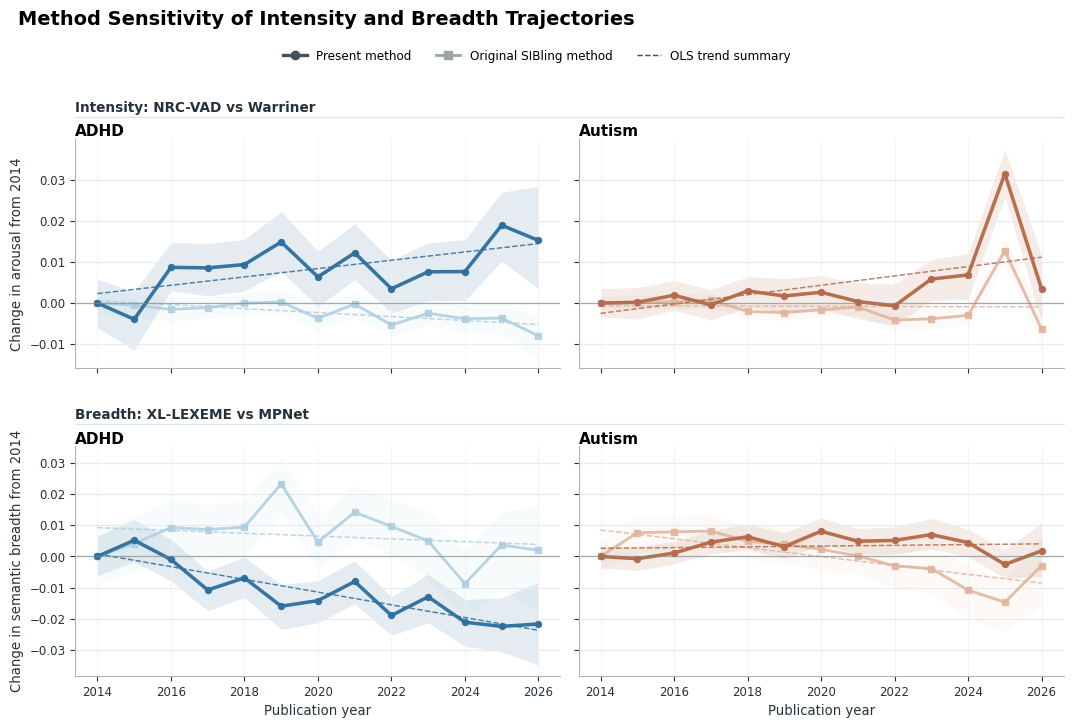

Wrote reports/figures/lsc/robustness/lsc_method_robustness_intensity_breadth.png
Wrote reports/figures/lsc/robustness/lsc_method_robustness_intensity_breadth.pdf
Wrote reports/tables/lsc/robustness/lsc_method_robustness_figure_data.csv


In [4]:
MEASURE_ORDER = ["Intensity", "Breadth"]
MEASURE_LABELS = {
    "Intensity": "Intensity: NRC-VAD vs Warriner",
    "Breadth": "Breadth: XL-LEXEME vs MPNet",
}
Y_LABELS = {
    "Intensity": "Change in arousal from 2014",
    "Breadth": "Change in semantic breadth from 2014",
}


def series_colour(unit: str, method_family: str) -> str:
    if method_family == "main":
        return UNIT_COLOURS[unit]
    return ROBUSTNESS_COLOURS[unit]


def style_axis(ax: plt.Axes) -> None:
    ax.grid(axis="y", color="#E7EBEE", linewidth=0.8)
    ax.grid(axis="x", color="#EEF1F3", linewidth=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#AAB4BC")
    ax.spines["bottom"].set_color("#AAB4BC")
    ax.set_xticks(EXPECTED_YEARS[::2])
    ax.tick_params(axis="x", labelsize=8.5)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.axhline(0, color="#7B8785", linewidth=0.9, alpha=0.65)


def plot_method_series(ax: plt.Axes, panel_data: pd.DataFrame) -> None:
    for _, series in panel_data.groupby(["method_family", "method_key"], sort=False):
        series = series.sort_values("lsc_year")
        unit = str(series["analysis_unit"].iloc[0])
        method_family = str(series["method_family"].iloc[0])
        color = series_colour(unit, method_family)
        ax.plot(
            series["lsc_year"],
            series["score_delta"],
            marker=METHOD_MARKERS[method_family],
            markersize=4.3 if method_family == "main" else 3.9,
            linewidth=2.55 if method_family == "main" else 2.05,
            color=color,
            alpha=0.96 if method_family == "main" else 0.88,
        )
        ax.fill_between(
            series["lsc_year"].to_numpy(dtype=float),
            series["ci_low_delta"].to_numpy(dtype=float),
            series["ci_high_delta"].to_numpy(dtype=float),
            color=color,
            alpha=0.13 if method_family == "main" else 0.08,
            linewidth=0,
        )
        ax.plot(
            series["lsc_year"],
            series["fitted_delta"],
            color=color,
            linewidth=1.05,
            linestyle="--",
            alpha=0.88,
        )


fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.25), sharex=True, sharey="row")

for row_index, measure in enumerate(MEASURE_ORDER):
    for col_index, unit in enumerate(TARGET_UNITS):
        ax = axes[row_index, col_index]
        panel_data = figure_data.loc[figure_data["measure"].eq(measure) & figure_data["analysis_unit"].eq(unit)]
        plot_method_series(ax, panel_data)
        style_axis(ax)
        ax.set_title(unit, loc="left", fontsize=11, fontweight="bold", pad=0)
        if col_index == 0:
            ax.set_ylabel(Y_LABELS[measure], fontsize=9.5)
        if row_index == 1:
            ax.set_xlabel("Publication year", fontsize=9.5)

legend_handles = [
    Line2D([0], [0], color="#44515C", marker=METHOD_MARKERS["main"], linewidth=2.4, label="Present method"),
    Line2D([0], [0], color="#9AA6A1", marker=METHOD_MARKERS["baes_check"], linewidth=2.0, label="Original SIBling method"),
    Line2D([0], [0], color="#44515C", linestyle="--", linewidth=1.05, label="OLS trend summary"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, fontsize=8.7, bbox_to_anchor=(0.5, 0.955))
fig.suptitle("Method Sensitivity of Intensity and Breadth Trajectories", fontsize=14, fontweight="bold", x=0.02, y=0.995, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.9], pad=1.0)
fig.subplots_adjust(hspace=0.34)
fig.canvas.draw()

for row_index, measure in enumerate(MEASURE_ORDER):
    left_position = axes[row_index, 0].get_position()
    right_position = axes[row_index, -1].get_position()
    label_y = left_position.y1 + 0.034
    fig.text(
        left_position.x0,
        label_y,
        MEASURE_LABELS[measure],
        ha="left",
        va="bottom",
        fontsize=9.8,
        fontweight="bold",
        color="#25313B",
    )
    fig.add_artist(
        Line2D(
            [left_position.x0, right_position.x1],
            [label_y - 0.003, label_y - 0.003],
            transform=fig.transFigure,
            color="#DDE4E8",
            linewidth=0.85,
        )
    )

fig.savefig(FIGURE_PATH, dpi=LSC_FIGURE_DPI, bbox_inches="tight", facecolor="white")
pdf_path = FIGURE_PATH.with_suffix(".pdf")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Wrote {FIGURE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {pdf_path.relative_to(PROJECT_ROOT)}")
print(f"Wrote {FIGURE_DATA_PATH.relative_to(PROJECT_ROOT)}")